#Implement data pre-processing
 **Used dataset** "Titanic - Machine Learning from Disaster"


In [ ]:
import numpy as np
import pandas as pd

# Read the dataset

In [ ]:

data=pd.read_csv('train.csv')

In [ ]:
#show the 5 rows
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#Handle Missing Values

**Check for missing values**

In [ ]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


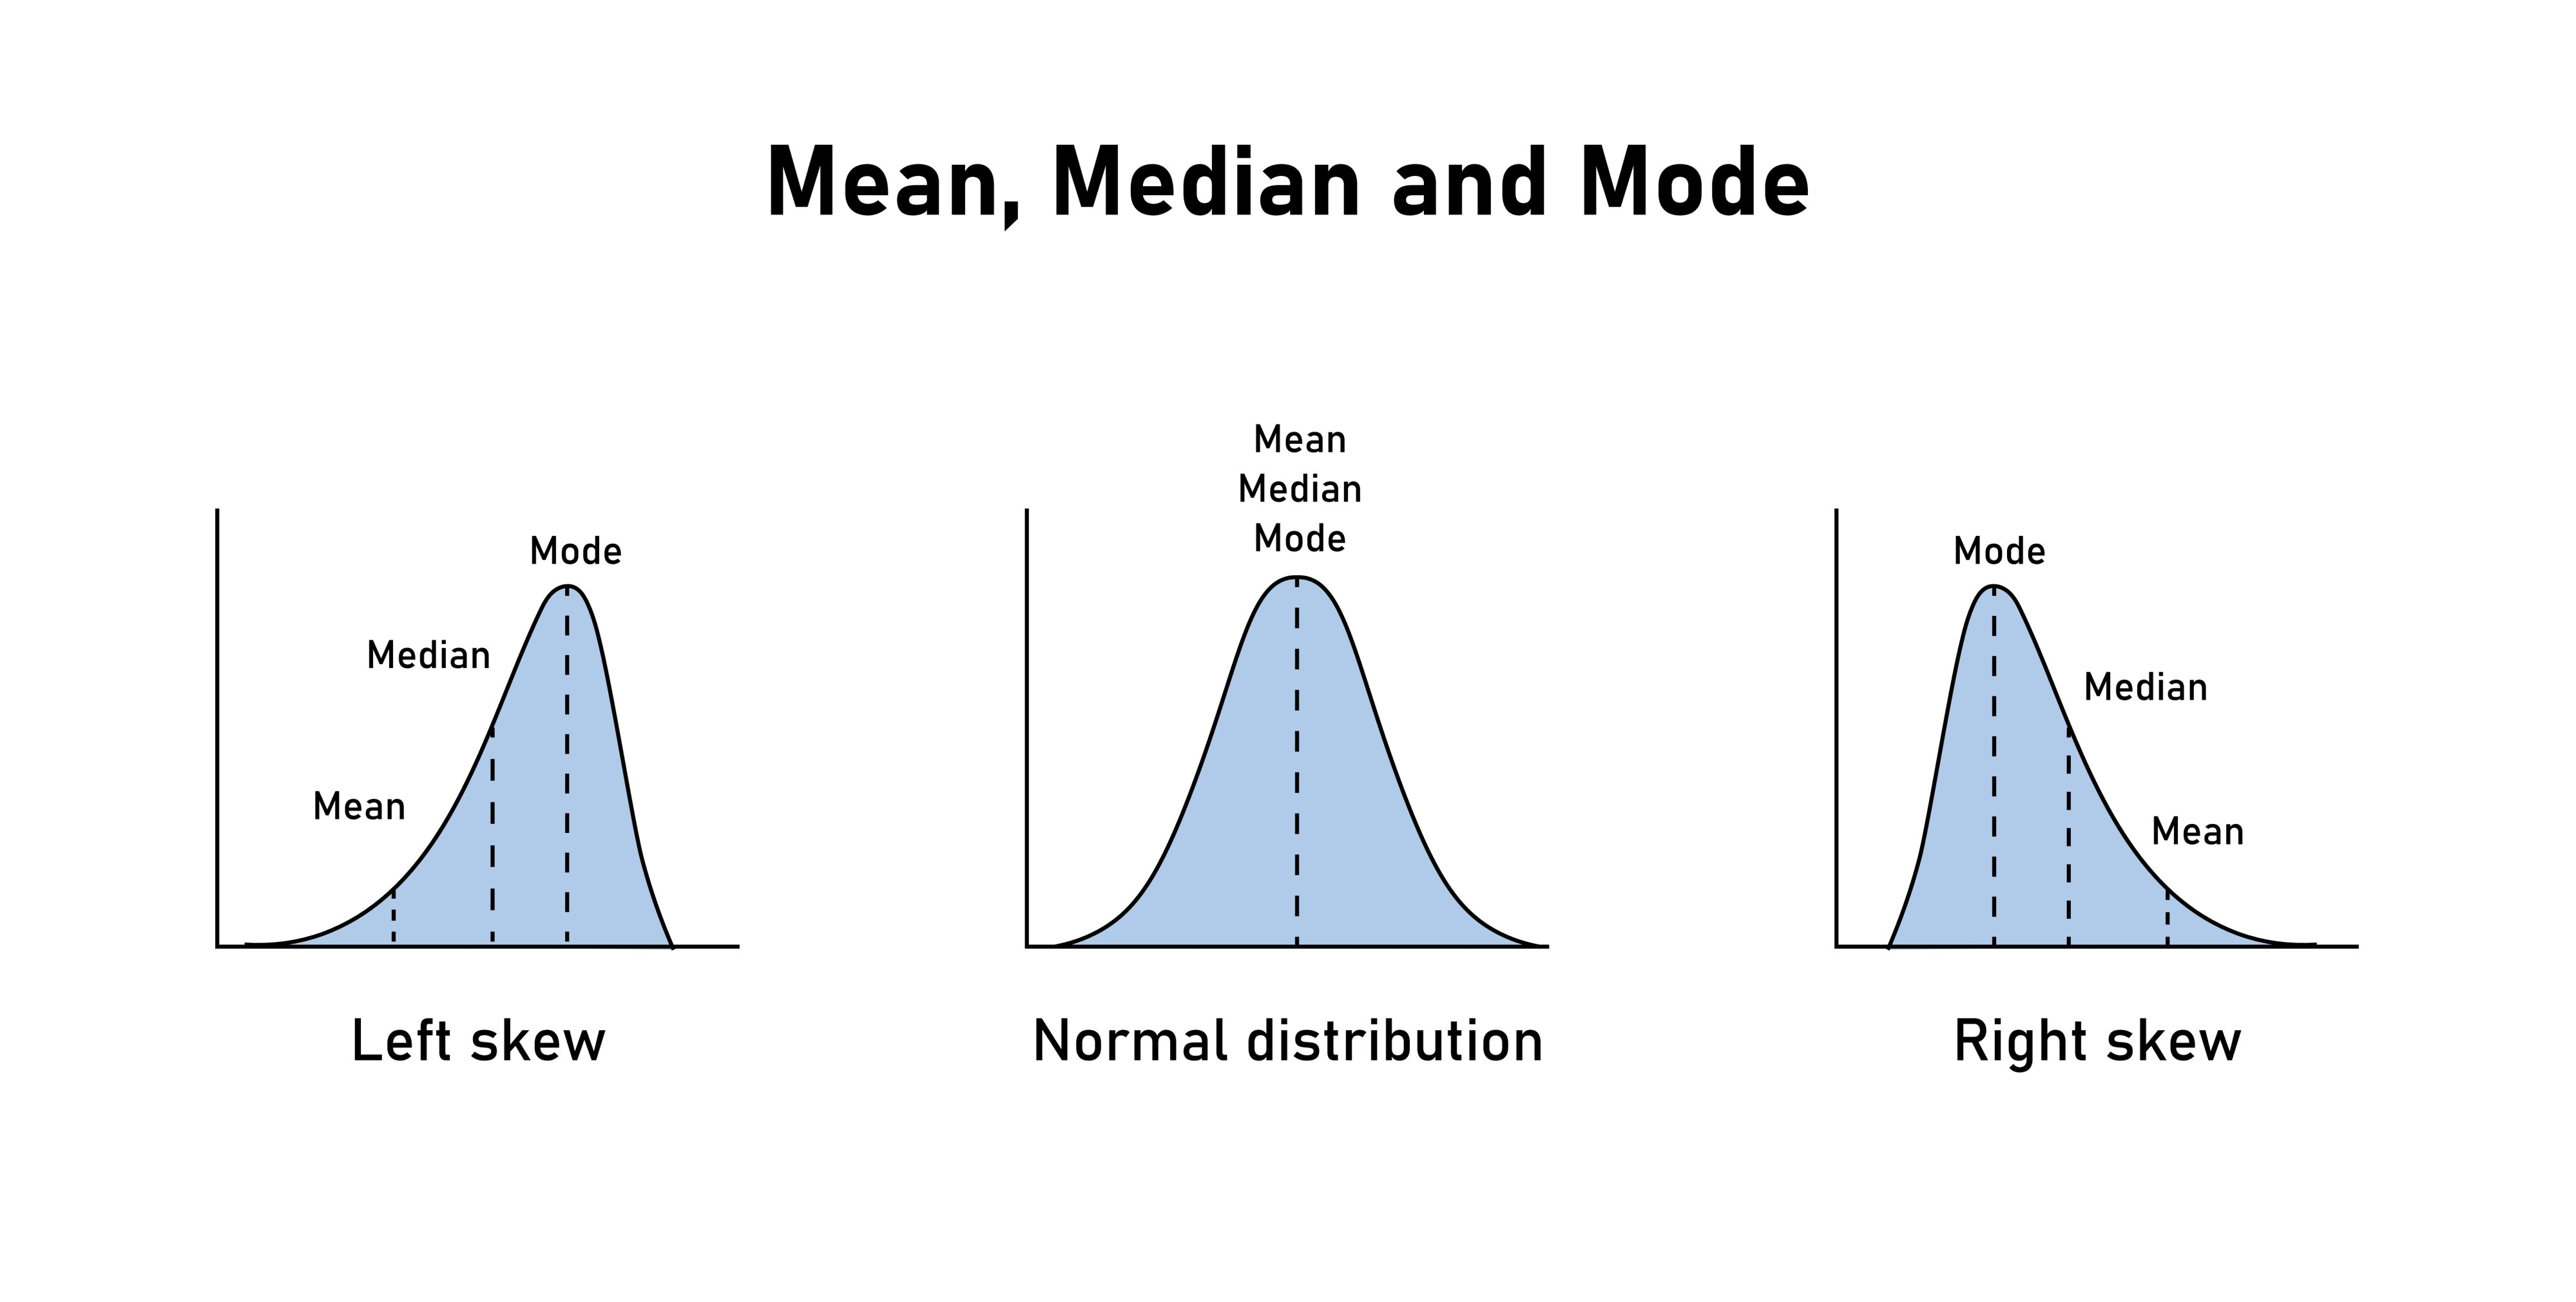

**Filling missing 'Age' with median because it is robust to outliers
and handles skewed data better than the mean.**



In [ ]:
data['Age'] = data['Age'].fillna(data['Age'].median())

**Filling missing 'Embarked' with mode because it is a categorical column.
we use the most frequent value to fill the gaps**

In [ ]:

data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])


**Drop columns with too many missing values (e.g., 'Cabin')**


In [ ]:
data = data.drop(columns=['Cabin'])

 # Encode Categorical Variables

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encoding 'Sex' column: Converting categorical 'male/female' to 0/1
# for the machine learning model to process numerical data.
le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])

In [ ]:
# Encoding 'Embarked' using One-Hot Encoding because it has more than 2 categories
# and there is no natural order (S, C, Q). This prevents the model from assuming any rank.
data = pd.get_dummies(data, columns=['Embarked'], drop_first=True)

In [ ]:
# Converting One-Hot encoded boolean columns to integers (0/1).
# This ensures 'Embarked_Q' and 'Embarked_S' are in numerical format for the model.
data[['Embarked_Q', 'Embarked_S']] = data[['Embarked_Q', 'Embarked_S']].astype(int)

# Feature Scaling

**Normalize numerical features like 'Age' and 'Fare'.**

In [ ]:
from sklearn.preprocessing import StandardScaler
# Select numerical columns
num_cols = ['Age', 'Fare']
s = StandardScaler()
# Scale the numerical columns
data[num_cols] = s.fit_transform(data[num_cols])

In [ ]:
data.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


#Split Data into Features and Target

**Prepare the dataset for model training**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
data=data.dropna(subset=['Age','Fare'])

In [ ]:
x=data[['Age']]
y=data[['Survived']]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
y_train

,Survived
331,0
733,0
382,0
704,0
813,0
...,...
106,1
270,0
860,0
435,1


In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
pre=model.predict(x_test)

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(y_test,pre)
r2=r2_score(y_test,pre)

print("MSE",mse)
print("R2",r2)

MSE 0.24145530098308457
R2 0.004315405559972563


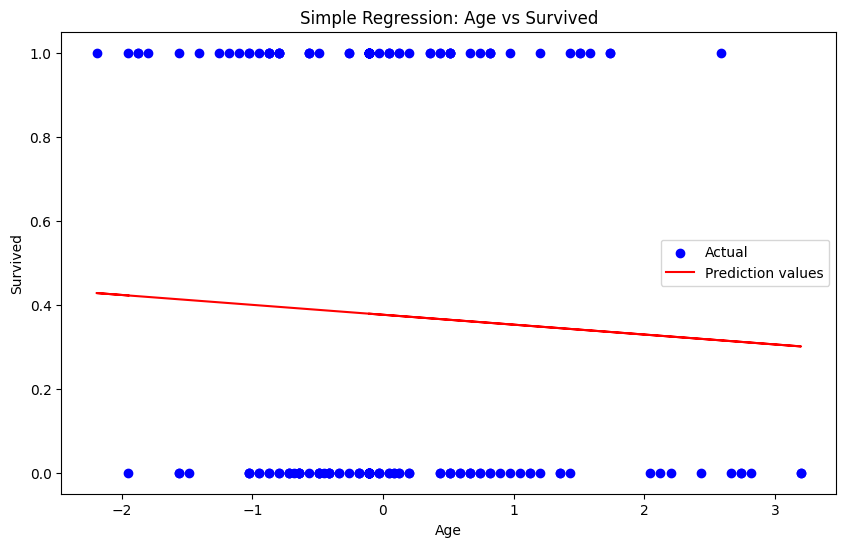

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(x_test['Age'], y_test, color='blue', label='Actual')
plt.plot(x_test['Age'], pre, color='red', label='Prediction values')
plt.xlabel("Age")
plt.ylabel('Survived')
plt.title("Simple Regression: Age vs Survived")
plt.legend()
plt.show()


